In [1]:
# FMA metadata: genres, splits, per-track info.
# Downloads into data/ at the repo root, rerun skips what is already there.
import urllib.request
import zipfile
from pathlib import Path

DATA_DIR = Path('../../data').resolve()
METADATA_URL = 'https://os.unil.cloud.switch.ch/fma/fma_metadata.zip'
METADATA_ZIP = DATA_DIR / 'fma_metadata.zip'
METADATA_DIR = DATA_DIR / 'fma_metadata'

DATA_DIR.mkdir(exist_ok=True)

if not METADATA_ZIP.exists():
    print('Downloading fma_metadata.zip (~342MB)...')
    urllib.request.urlretrieve(METADATA_URL, METADATA_ZIP)

if not METADATA_DIR.exists():
    print('Extracting...')
    with zipfile.ZipFile(METADATA_ZIP) as z:
        z.extractall(DATA_DIR)

print(*sorted(p.name for p in METADATA_DIR.iterdir()), sep='\n')

README.txt
checksums
echonest.csv
features.csv
genres.csv
not_found.pickle
raw_albums.csv
raw_artists.csv
raw_echonest.csv
raw_genres.csv
raw_tracks.csv
tracks.csv


Tracks in medium: 25000
Tracks without a top genre: 0
(track, genre_top)
Rock                   7103
Electronic             6314
Experimental           2251
Hip-Hop                2201
Folk                   1519
Instrumental           1350
Pop                    1186
International          1018
Classical               619
Old-Time / Historic     510
Jazz                    384
Country                 178
Soul-RnB                154
Spoken                  118
Blues                    74
Easy Listening           21
Name: count, dtype: int64


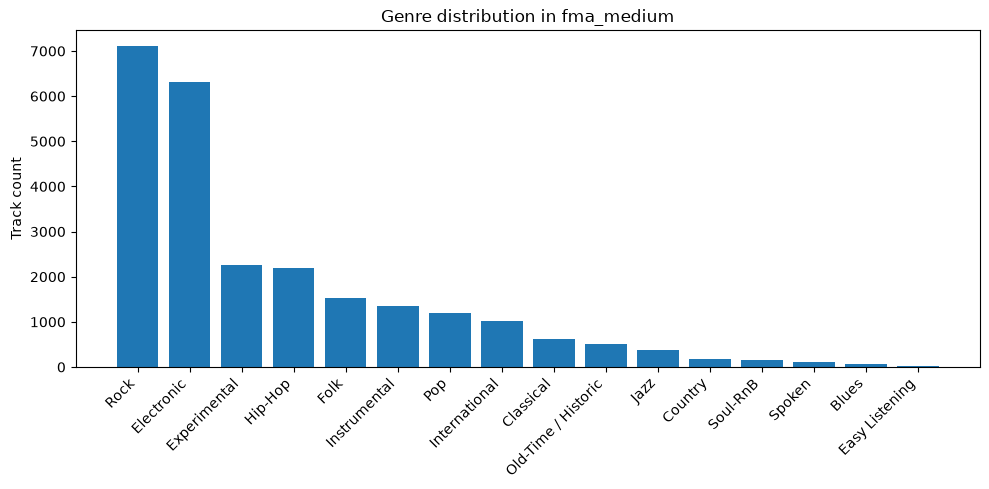

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# tracks.csv has two-level headers (group, field), hence header=[0, 1]
tracks = pd.read_csv(METADATA_DIR / 'tracks.csv', index_col=0, header=[0, 1])

# the medium subset includes small
medium = tracks[tracks[('set', 'subset')].isin(['small', 'medium'])]
genre_counts = medium[('track', 'genre_top')].value_counts()

print(f'Tracks in medium: {len(medium)}')
print(f'Tracks without a top genre: {medium[("track", "genre_top")].isna().sum()}')
print(genre_counts)

plt.figure(figsize=(10, 5))
plt.bar(genre_counts.index, genre_counts.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Track count')
plt.title('Genre distribution in fma_medium')
plt.tight_layout()
plt.show()

У medium 25000 треків і 16 top-жанрів, дисбаланс великий: Rock 7103 проти Easy Listening 21.

Рішення по класах:

- Easy Listening (21) і Blues (74) викидаємо - замало даних навіть для нормальної валідації.
- Rock і Electronic обрізаємо до 3000 випадкових треків (seed=42), щоб вони не домінували в тренуванні.
- Spoken (118) лишаємо свідомо як експеримент: цікаво, чи вивчиться мова як окремий клас.

Разом лишається 14 класів. Спліт train/val/test беремо офіційний з метаданих (колонка ('set', 'split')) - він зроблений з урахуванням артистів, тож один артист не потрапляє одночасно в train і test (без artist leakage). Спліт завжди по треках, ніколи по вікнах.